# Import libraries

In [ ]:
! pip install lazypredict

In [2]:
!pip install xgboost -q

## Import dataset

In [3]:
! wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/final_dataset_preprocessed_distributed_social_class.csv

--2026-08-16 04:49:23--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/final_dataset_preprocessed_distributed_social_class.csv
Resolving huggingface.co (huggingface.co)... 13.226.251.20, 13.226.251.81, 13.226.251.112, ...
Connecting to huggingface.co (huggingface.co)|13.226.251.20|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/6a7c7183f2c81824bdfb6fa9/e667362f3c877b4bc4e46b95a9b7382d66b4e3037af217c9b916437c0c549fcc?user_id=public&response-content-type=text%2Fcsv&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27final_dataset_preprocessed_distributed_social_class.csv%3B+filename%3D%22final_dataset_preprocessed_distributed_social_class.csv%22%3B&X-Xet-Cas-Uid=public&Expires=1786859363&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmE3YzcxODNmMmM4MTgyNGJkZmI2ZmE5L2U2NjczNjJmM2M4NzdiNGJjNGU0NmI5NWE5YjczODJkNjZiNGUzMDM3YWYyMTdjOWI5MTY0MzdjMGM1NDlm

## Import Libraries

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [5]:
dataset = pd.read_csv('final_dataset_preprocessed_distributed_social_class.csv')
dataset.head()

,age,education_years,weekly_workhours,digital_index,social_participation_index,gender_male,disabled,social_participant,agri_worker,disability_severity_ord,...,no_disability,digital_status,workhours_missing,income_class,region_Bali_Nusa,region_Eastern,region_Java,region_Kalimantan,region_Sulawesi,region_Sumatra
0,78.0,6.0,0.0,0.0,0.333333,1,0,1,0,0,...,1,0,1,No_income,0,0,0,0,0,1
1,65.0,6.0,0.0,0.0,0.333333,0,0,1,0,0,...,1,0,1,No_income,0,0,0,0,0,1
2,82.0,6.0,0.0,0.0,0.000000,1,0,0,0,0,...,1,0,1,No_income,0,0,0,0,0,1
3,65.0,6.0,0.0,0.0,0.000000,0,0,0,0,0,...,1,0,1,No_income,0,0,0,0,0,1
4,31.0,12.0,35.0,1.0,0.333333,1,0,1,0,0,...,1,2,0,Lower,0,0,0,0,0,1


In [6]:
X = dataset.drop('income_class', axis=1)
y = dataset['income_class']

In [ ]:
X

,age,education_years,weekly_workhours,digital_index,social_participation_index,gender_male,disabled,social_participant,agri_worker,disability_severity_ord,...,disability_hand_finger,no_disability,digital_status,workhours_missing,region_Bali_Nusa,region_Eastern,region_Java,region_Kalimantan,region_Sulawesi,region_Sumatra
0,78.0,6.0,0.0,0.0,0.333333,1,0,1,0,0,...,0,1,0,1,0,0,0,0,0,1
1,65.0,6.0,0.0,0.0,0.333333,0,0,1,0,0,...,0,1,0,1,0,0,0,0,0,1
2,82.0,6.0,0.0,0.0,0.000000,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
3,65.0,6.0,0.0,0.0,0.000000,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
4,31.0,12.0,35.0,1.0,0.333333,1,0,1,0,0,...,0,1,2,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751617,25.0,1.0,36.0,0.0,0.333333,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
751618,33.0,1.0,36.0,0.0,0.333333,1,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
751619,25.0,1.0,36.0,0.0,0.333333,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
751620,36.0,1.0,36.0,0.0,0.333333,1,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0


In [7]:
y

,income_class
0,No_income
1,No_income
2,No_income
3,No_income
4,Lower
...,...
751617,No_income
751618,Middle
751619,No_income
751620,Middle


## Splitting the dataset into the Training set and Test set

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [ ]:
print(X_train)

         age  education_years  weekly_workhours  digital_index  \
198372  15.0              9.0               0.0            0.0   
560962  46.0              6.0              48.0            0.0   
161858  55.0              6.0              48.0            0.0   
123453  46.0              9.0              56.0            0.0   
84898   59.0             12.0              36.0            0.0   
...      ...              ...               ...            ...   
259178  30.0              6.0              63.0            2.0   
365838  43.0              6.0              56.0            1.0   
131932  28.0             12.0               0.0            0.0   
671155  34.0             12.0              56.0            1.0   
121958  20.0             12.0              70.0            0.0   

        social_participation_index  gender_male  disabled  social_participant  \
198372                    0.333333            0         0                   1   
560962                    0.333333           

In [9]:
print(y_train)

198372    No_income
560962       Middle
161858       Middle
123453        Lower
84898         Lower
            ...    
259178        Lower
365838        Lower
131932    No_income
671155        Lower
121958        Lower
Name: income_class, Length: 601297, dtype: object


## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
print(X_train)

[[-1.56327321  0.04303375 -1.12152614 ... -0.3392775  -0.41857732
   1.54701239]
 [ 0.32026504 -0.64070429  0.97569275 ...  2.94743979 -0.41857732
  -0.64640723]
 [ 0.86709873 -0.64070429  0.97569275 ... -0.3392775  -0.41857732
   1.54701239]
 ...
 [-0.77340233  0.7267718  -1.12152614 ... -0.3392775  -0.41857732
   1.54701239]
 [-0.40884654  0.7267718   1.32522923 ... -0.3392775   2.38904485
  -0.64640723]
 [-1.25947671  0.7267718   1.93691808 ... -0.3392775  -0.41857732
   1.54701239]]


In [ ]:
print(y_train)

198372    No_income
560962       Middle
161858       Middle
123453        Lower
84898         Lower
            ...    
259178        Lower
365838        Lower
131932    No_income
671155        Lower
121958        Lower
Name: income_class, Length: 601297, dtype: object


## Training the Decision Tree Classification model on the Training set

In [10]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
# does the training frame even have the new column?
print('workhours_missing' in X.columns)
print(X['workhours_missing'].value_counts()) if 'workhours_missing' in X.columns else print("NOT PRESENT — that's the bug")

True
workhours_missing
0    502425
1    249197
Name: count, dtype: int64


## Predicting the Test set results

In [11]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.values.reshape(len(y_test),1)),1))

[['No_income' 'No_income']
 ['Lower' 'Middle']
 ['Middle' 'Middle']
 ...
 ['No_income' 'No_income']
 ['No_income' 'Lower']
 ['No_income' 'No_income']]


## Making the Confusion Matrix

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[29764 11959  5753   374]
 [14617 18290  1463   809]
 [ 7842  1489 56197    43]
 [  464  1055    56   150]]


0.6945019125228671

## Classification summary

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Lower       0.56      0.62      0.59     47850
      Middle       0.56      0.52      0.54     35179
   No_income       0.89      0.86      0.87     65571
       Upper       0.11      0.09      0.10      1725

    accuracy                           0.69    150325
   macro avg       0.53      0.52      0.52    150325
weighted avg       0.70      0.69      0.70    150325



# Check Class Balanced

In [14]:
print(y.value_counts(normalize=True))

print("Train acc:", classifier.score(X_train, y_train))
print("Test acc:", classifier.score(X_test, y_test))

income_class
No_income    0.436340
Lower        0.318544
Middle       0.234038
Upper        0.011077
Name: proportion, dtype: float64
Train acc: 0.9028649735488452
Test acc: 0.6945019125228671


# Tree Pruning

In [15]:
from sklearn.tree import DecisionTreeClassifier

pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=20,
    min_samples_leaf=50,
    random_state=42
)
pruned.fit(X_train, y_train)
print("Train acc:", pruned.score(X_train, y_train))
print("Test acc:", pruned.score(X_test, y_test))

Train acc: 0.7514788864737393
Test acc: 0.747626808581407


# Random Forest Baseline

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Test acc:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Test acc: 0.7536071844337269


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Lower       0.62      0.73      0.67     47850
      Middle       0.66      0.62      0.64     35179
   No_income       0.94      0.86      0.90     65571
       Upper       0.00      0.00      0.00      1725

    accuracy                           0.75    150325
   macro avg       0.55      0.55      0.55    150325
weighted avg       0.76      0.75      0.75    150325



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# XG Boost Baseline

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train_enc)
y_pred_xgb = xgb.predict(X_test)
print("Test acc:", accuracy_score(y_test_enc, y_pred_xgb))
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

       Lower       0.62      0.68      0.65     47850
      Middle       0.60      0.56      0.58     35179
   No_income       0.97      0.83      0.89     65571
       Upper       0.10      0.48      0.16      1725

    accuracy                           0.71    150325
   macro avg       0.57      0.64      0.57    150325
weighted avg       0.76      0.71      0.73    150325



# XGBOOST Hyper parameter tuning

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

param_dist = {
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [200, 400, 600],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb = XGBClassifier(n_jobs=-1, random_state=42, eval_metric='mlogloss')

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    n_jobs=1,
    random_state=42
)

search.fit(X_train, y_train_enc, sample_weight=sample_weights)

print("Best params:", search.best_params_)
print("Best CV f1_macro:", search.best_score_)

best_xgb = search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
print(classification_report(y_test_enc, y_pred_best, target_names=le.classes_))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.6; total time=  55.4s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.6; total time=  42.3s
[CV] END colsample_bytree=0.6, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.6; total time=  44.7s
[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=8, min_child_weight=10, n_estimators=200, subsample=1.0; total time=  51.6s
[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=8, min_child_weight=10, n_estimators=200, subsample=1.0; total time=  51.3s
[CV] END colsample_bytree=0.6, learning_rate=0.2, max_depth=8, min_child_weight=10, n_estimators=200, subsample=1.0; total time=  50.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=10, min_child_weight=1, n_estimators=600, subsample=0.6; total 

# Feature Importance

In [21]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

weekly_workhours              0.357169
workhours_missing             0.275786
age                           0.077200
digital_index                 0.077033
digital_status                0.068306
gender_male                   0.066404
education_years               0.025264
social_participation_index    0.019954
agri_worker                   0.013074
region_Java                   0.003253
region_Kalimantan             0.003176
region_Eastern                0.002452
region_Bali_Nusa              0.002133
region_Sumatra                0.001632
disability_severity_ord       0.001466
dtype: float64


# Multinominal Logistic Regression

In [23]:
df_model = (
    dataset.sample(n=100_000, random_state=42)
    if len(dataset) > 150_000
    else dataset.copy()
)

In [33]:
print(df_model['income_class_code'].dtype)
print(df_model['income_class_code'].unique())
print(df_model['income_class_code'].isna().sum())

category
[0, 2, 1, 3]
Categories (4, int64): [0, 1, 2, 3]
0


In [34]:
df_model['income_class_code'] = df_model['income_class_code'].astype(int)

print(df_model['income_class_code'].dtype)

int64


In [36]:
import statsmodels.api as sm

feature_cols = [
    'digital_index', 'age', 'education_years', 'weekly_workhours',
    'gender_male', 'disabled', 'social_participation_index',
    'region_Bali_Nusa', 'region_Eastern', 'region_Kalimantan',
    'region_Sulawesi', 'region_Sumatra'
]

df_model_clean = df_model.dropna(subset=['income_class_code'] + feature_cols)

X_reg = sm.add_constant(df_model_clean[feature_cols].astype(float))
y_reg = df_model_clean['income_class_code'].astype(int)  # force plain int here too

mnlogit_model = sm.MNLogit(y_reg, X_reg).fit(method='newton', maxiter=100)
print(mnlogit_model.summary())

Optimization terminated successfully.
         Current function value: 0.641299
         Iterations 10
                          MNLogit Regression Results                          
Dep. Variable:      income_class_code   No. Observations:               100000
Model:                        MNLogit   Df Residuals:                    99961
Method:                           MLE   Df Model:                           36
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                  0.4254
Time:                        07:52:59   Log-Likelihood:                -64130.
converged:                       True   LL-Null:                   -1.1160e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
       income_class_code=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -4.5903      0.060    -76.434      0.000     

#  Plot 1: digital_index odds ratio gradient across income classes

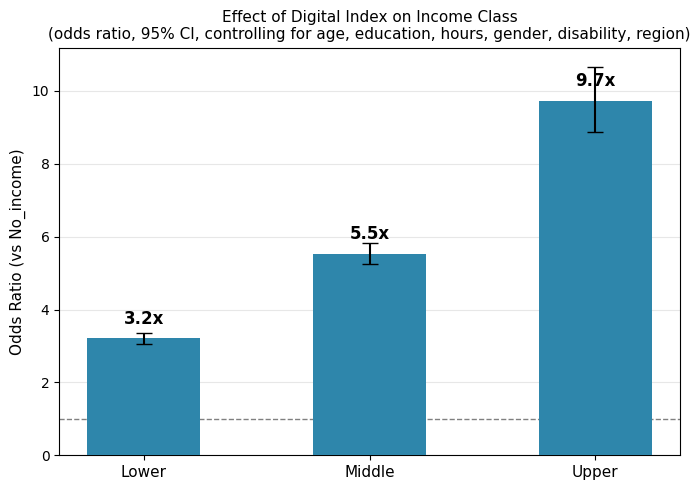

In [37]:
classes = ['Lower', 'Middle', 'Upper']
coefs = [1.1663, 1.7113, 2.2747]
ci_low = [1.119, 1.660, 2.184]
ci_high = [1.214, 1.762, 2.366]

odds_ratios = np.exp(coefs)
or_low = np.exp(ci_low)
or_high = np.exp(ci_high)
err_low = odds_ratios - or_low
err_high = or_high - odds_ratios

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(classes))

ax.bar(x, odds_ratios, color='#2E86AB', width=0.5, zorder=3)
ax.errorbar(x, odds_ratios, yerr=[err_low, err_high], fmt='none',
            ecolor='black', elinewidth=1.5, capsize=6, zorder=4)

for i, v in enumerate(odds_ratios):
    ax.text(i, v + 0.4, f'{v:.1f}x', ha='center', fontsize=12, fontweight='bold')

ax.axhline(1, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylabel('Odds Ratio (vs No_income)', fontsize=11)
ax.set_title('Effect of Digital Index on Income Class\n(odds ratio, 95% CI, controlling for age, education, hours, gender, disability, region)',
             fontsize=11)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('digital_index_odds_ratio.png', dpi=150)
plt.show()


# Plot 2: disability type profile by income class (radar)

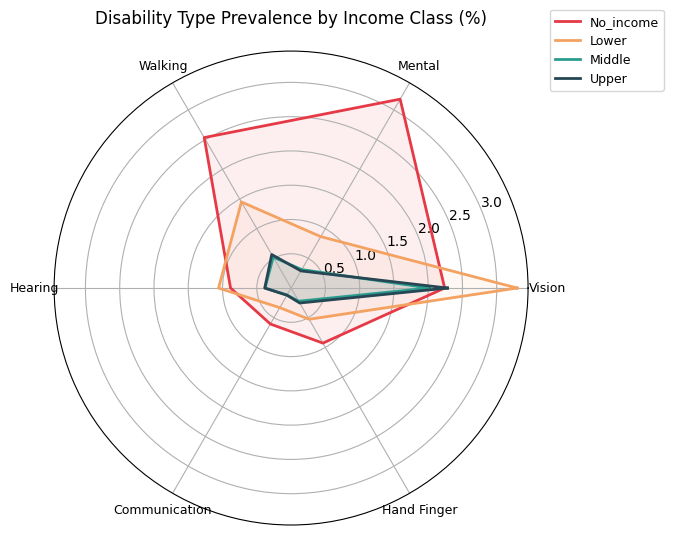

In [39]:
disability_cols = ['disability_vision', 'disability_mental', 'disability_walking',
                    'disability_hearing', 'disability_communication', 'disability_hand_finger']

# % of each income class that has each disability type
radar_data = dataset.groupby('income_class', observed=True)[disability_cols].mean() * 100

labels = [c.replace('disability_', '').replace('_', ' ').title() for c in disability_cols]
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = {'No_income': '#E63946', 'Lower': '#F4A261', 'Middle': '#2A9D8F', 'Upper': '#264653'}

for income_class in ['No_income', 'Lower', 'Middle', 'Upper']:
    if income_class not in radar_data.index:
        continue
    values = radar_data.loc[income_class].tolist()
    values += values[:1]
    ax.plot(angles, values, label=income_class, color=colors.get(income_class), linewidth=2)
    ax.fill(angles, values, alpha=0.08, color=colors.get(income_class))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_title('Disability Type Prevalence by Income Class (%)', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('disability_radar.png', dpi=150)
plt.show()